In [1]:
# !conda env export --file environment.yml
# !pip freeze > requirements.txt

In [2]:
# https://github.com/ThisIsJorgeLima/movielens/blob/master/SVD_Model.ipynb
# algorithm
# !~/.conda/envs/content_rating/bin/pip install -U scikit-learn
# from sklearn.neighbors import NearestNeighbors

# sparse matrix13356439
# from scipy.sparse import csr_matrix

# string matching
# !~/.conda/envs/content_rating/bin/pip install fuzzywuzzy
# !~/.conda/envs/content_rating/bin/pip install python-Levenshtein
# ! pip install scikit-learn
# ! pip install fuzzywuzzy
# ! pip install python-Levenshtein
# ! pip install sparse==0.1.1

#classics
import pandas as pd
import numpy as np
import os
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split

In [3]:
data_path = "/home/hhyamamura/workspace/contentRecommendation/ml-25m/"
movies_filename = 'movies.csv'
ratings_filename = 'ratings.csv'

#read data

movies = pd.read_csv(
    os.path.join(data_path, movies_filename),
    usecols=['movieId', 'title', 'genres'],
    dtype={'movieId': 'int32', 'title': 'str'})

ratings = pd.read_csv(
    os.path.join(data_path, ratings_filename),
    usecols=['userId', 'movieId', 'rating', 'timestamp'],
    dtype={'userId': 'int32', 'movieId': 'int32', 'rating': 'float32'})

# Rename the columns to match the required format
movies.rename(columns={'movieId': 'movie_id', 'title': 'title', 'genres': 'genres'}, inplace=True)
ratings.rename(columns={'userId': 'user_id', 'movieId': 'movie_id', 'rating': 'rating', 'timestamp': 'timestamp'}, inplace=True)

In [4]:
# Aggregate the total number of ratings per userId and rename the column to 'qtyRatings'
ratings_per_user = ratings.groupby('user_id').size().reset_index(name='qtyRatings')

# Sort the userId in descending order based on the total number of ratings
ratings_per_user_sorted = ratings_per_user.sort_values(by='qtyRatings', ascending=False)

In [5]:
# Extract the 'qtyRatings' column
data = ratings_per_user_sorted['qtyRatings']

# Calculate the quartiles and interquartile range (IQR)
Q1 = np.percentile(data, 25)
Q3 = np.percentile(data, 75)
IQR = Q3 - Q1

# Calculate the median
median = np.median(data)

# Calculate the minimum and maximum values
minimum = np.min(data)
maximum = np.max(data)

# Calculate the lower and upper bounds for outliers
k = 2.5 # When k = 1.5 Tukey’s Fences becomes IQR
lower_bound = Q1 - k * IQR
upper_bound = Q3 + k * IQR

# Identify the outliers
outliers = data[(data < lower_bound) | (data > upper_bound)]

# Print the statistics
print(f"Minimum: {minimum}")
print(f"Maximum: {maximum}")
print(f"Median: {median}")
print(f"1st Quartile (Q1): {Q1}")
print(f"3rd Quartile (Q3): {Q3}")
print(f"Interquartile Range (IQR): {IQR}")
print(f"Lower Bound for Outliers: {lower_bound}")
print(f"Upper Bound for Outliers: {upper_bound}")

# Identify outliers
df_user_outliers = ratings_per_user_sorted[(ratings_per_user_sorted['qtyRatings'] < lower_bound) |
                                            (ratings_per_user_sorted['qtyRatings'] > upper_bound)
                                            ]

# Print out the userIds that are outliers
print("Outlier userIds (sorted by qty ratings):\n", df_user_outliers.sort_values(by='qtyRatings'))

Minimum: 20
Maximum: 32202
Median: 71.0
1st Quartile (Q1): 36.0
3rd Quartile (Q3): 162.0
Interquartile Range (IQR): 126.0
Lower Bound for Outliers: -279.0
Upper Bound for Outliers: 477.0
Outlier userIds (sorted by qty ratings):
         user_id  qtyRatings
11232     11233         478
52511     52512         478
88407     88408         478
56080     56081         478
81220     81221         478
...         ...         ...
20054     20055        7488
33843     33844        7919
137292   137293        8913
80973     80974        9178
72314     72315       32202

[10413 rows x 2 columns]


In [6]:
# remove all df_user_outliers
ratings = ratings[~ratings['user_id'].isin(df_user_outliers['user_id'])]

In [7]:
# Get unique users
unique_users = ratings['user_id'].unique()

# Seed for reproducibility
SEED = 42

# Split users into train (70%), test (15%), and validation (15%)
training_ratio=0.85
train_users, val_users = train_test_split(unique_users, test_size=(1-training_ratio), random_state=SEED)

# Create masks to filter the dataframes
train_mask = ratings['user_id'].isin(train_users)
val_mask = ratings['user_id'].isin(val_users)

# Split the data
train_ratings = ratings[train_mask]
val_ratings = ratings[val_mask]

train_ratings.loc[:, 'rating'] = train_ratings['rating']
val_ratings.loc[:, 'rating'] = val_ratings['rating']

print(f"Training set size: {len(train_ratings)}")
print(f"Validation set size: {len(val_ratings)}")

Training set size: 13356439
Validation set size: 2341681


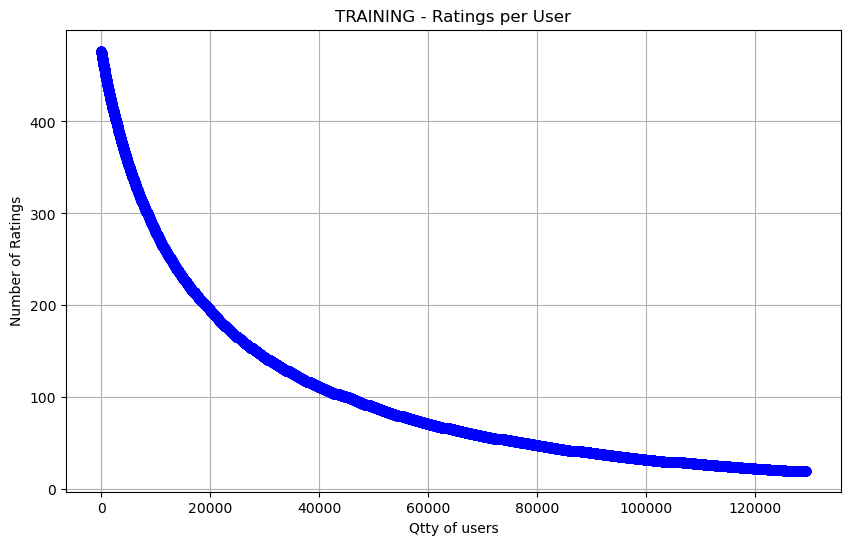

In [8]:
# Aggregate the total number of ratings per user_id and rename the column to 'qtyRatings'
ratings_per_user = train_ratings.groupby('user_id').size().reset_index(name='qtyRatings')

# Sort the user_id in descending order based on the total number of ratings
ratings_per_user_sorted = ratings_per_user.sort_values(by='qtyRatings', ascending=False)

x_data = ratings_per_user_sorted.reset_index(drop=True).index
qty_ratings = ratings_per_user_sorted['qtyRatings'].values

# Sort the user_id in descending order based on the total number of ratings
# used semilog graph to see how thigs are going
plt.figure(figsize=(10, 6))
plt.plot(x_data, qty_ratings, marker='o', linestyle='-', color='b')

plt.title('TRAINING - Ratings per User')
plt.xlabel('Qtty of users')
plt.ylabel('Number of Ratings')
plt.grid(True)
plt.show()

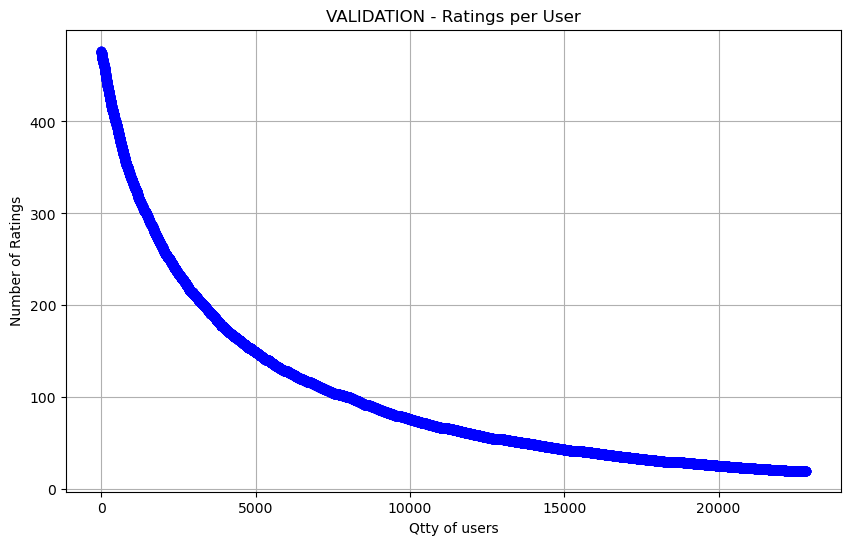

In [9]:
# Aggregate the total number of ratings per user_id and rename the column to 'qtyRatings'
ratings_per_user = val_ratings.groupby('user_id').size().reset_index(name='qtyRatings')

# Sort the user_id in descending order based on the total number of ratings
ratings_per_user_sorted = ratings_per_user.sort_values(by='qtyRatings', ascending=False)

x_data = ratings_per_user_sorted.reset_index(drop=True).index
qty_ratings = ratings_per_user_sorted['qtyRatings'].values

# Sort the user_id in descending order based on the total number of ratings
# used semilog graph to see how thigs are going
plt.figure(figsize=(10, 6))
plt.plot(x_data, qty_ratings, marker='o', linestyle='-', color='b')

plt.title('VALIDATION - Ratings per User')
plt.xlabel('Qtty of users')
plt.ylabel('Number of Ratings')
plt.grid(True)
plt.show()

In [10]:
# Count the number of unique users and movies
n_users = ratings.user_id.unique().shape[0]
n_movies = movies.movie_id.unique().shape[0]
print('Number of users = ' + str(n_users) + ' | Number of movies = ' + str(n_movies))

Number of users = 152128 | Number of movies = 62423


In [11]:
# Ratings = ratings.pivot(index = 'user_id', columns ='movie_id', values = 'rating').fillna(0)
Ratings = train_ratings.pivot(index = 'user_id', columns ='movie_id', values = 'rating').fillna(0)
Ratings.head()

/tmp/ipykernel_786827/1911298657.py:2: PerformanceWarning: The following operation may generate 4314878652 cells in the resulting pandas object.
  Ratings = train_ratings.pivot(index = 'user_id', columns ='movie_id', values = 'rating').fillna(0)


movie_id,1,2,3,4,5,6,7,8,9,10,...,209135,209137,209139,209141,209143,209145,209147,209157,209169,209171
user_id,,,,,,,,,,,,,,,,,,,,,
2,3.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,4.0,0.0,4.0,0.0,0.0,3.0,1.0,0.0,0.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [12]:
R = Ratings.to_numpy()

user_ratings_mean = np.mean(R, axis = 1)
Ratings_demeaned = R - user_ratings_mean.reshape(-1, 1)

In [13]:
sparsity = round(1.0 - len(ratings) / float(n_users * n_movies), 3)
print('The sparsity level of MovieLens25M dataset is ' +  str(sparsity * 100) + '%')

The sparsity level of MovieLens25M dataset is 99.8%


In [14]:
from scipy.sparse.linalg import svds
U, sigma, Vt = svds(Ratings_demeaned, k = 50)

In [15]:
sigma = np.diag(sigma)

In [16]:
all_user_predicted_ratings = np.dot(np.dot(U, sigma), Vt) + user_ratings_mean.reshape(-1, 1)

In [17]:
preds = pd.DataFrame(all_user_predicted_ratings, columns = Ratings.columns)
preds.head()

movie_id,1,2,3,4,5,6,7,8,9,10,...,209135,209137,209139,209141,209143,209145,209147,209157,209169,209171
0,5.348104,0.411339,-0.018156,0.036797,-0.097273,0.338843,0.273175,0.051210,-0.074623,0.666285,...,0.003193,0.003178,0.003193,0.003193,0.003193,0.003193,0.003193,0.003138,0.003113,0.003113
1,3.005985,0.215361,0.072382,0.037089,0.103957,0.069955,0.159042,0.018287,-0.010600,0.469142,...,0.000745,0.000721,0.000745,0.000745,0.000745,0.000745,0.000745,0.000685,0.000673,0.000673
2,3.843144,0.822772,1.405503,0.171059,1.224882,1.673696,1.096672,0.116522,0.531746,1.028330,...,-0.000055,-0.000058,-0.000055,-0.000055,-0.000055,-0.000055,-0.000055,-0.000007,0.000048,0.000048
3,0.843806,-0.100622,-0.314087,-0.016333,-0.141728,-0.349418,-0.080149,-0.053877,-0.138302,1.385620,...,-0.000135,-0.000140,-0.000135,-0.000135,-0.000135,-0.000135,-0.000135,-0.000034,0.000077,0.000077
4,4.078068,0.591289,0.988790,0.057120,0.687023,3.314059,0.852915,0.087560,0.602919,2.328841,...,-0.001297,-0.001300,-0.001297,-0.001297,-0.001297,-0.001297,-0.001297,-0.001343,-0.001383,-0.001383


In [18]:
def recommend_movies(predictions, userID, movies, original_ratings, num_recommendations):
    
    # Get and sort the user's predictions
    user_row_number = userID - 1 # User ID starts at 1, not 0
    sorted_user_predictions = preds.iloc[user_row_number].sort_values(ascending=False) # User ID starts at 1
    
    # Get the user's data and merge in the movie information.
    user_data = original_ratings[original_ratings.user_id == (userID)]
    user_full = (user_data.merge(movies, how = 'left', left_on = 'movie_id', right_on = 'movie_id').
                     sort_values(['rating'], ascending=False)
                 )

    print('User {0} has already rated {1} movies.'.format(userID, user_full.shape[0]))
    print('Recommending highest {0} predicted ratings movies not already rated.'.format(num_recommendations))
    
    # Recommend the highest predicted rating movies that the user hasn't seen yet.
    recommendations = (movies[~movies['movie_id'].isin(user_full['movie_id'])].
         merge(pd.DataFrame(sorted_user_predictions).reset_index(), how = 'left',
               left_on = 'movie_id',
               right_on = 'movie_id').
         rename(columns = {user_row_number: 'Predictions'}).
         sort_values('Predictions', ascending = False).
                       iloc[:num_recommendations, :-1]
                      )

    return user_full, recommendations

In [19]:
already_rated, predictions = recommend_movies(preds, 1310, movies, ratings, 20)

User 1310 has already rated 21 movies.
Recommending highest 20 predicted ratings movies not already rated.


In [20]:
# Top 20 movies that User 1310 has rated 
already_rated.head(20)

,user_id,movie_id,rating,timestamp,title,genres
20,1310,1721,5.0,884629656,Titanic (1997),Drama|Romance
15,1310,1639,5.0,884630325,Chasing Amy (1997),Comedy|Drama|Romance
3,1310,1414,4.0,884630054,Mother (1996),Comedy
2,1310,1407,4.0,884629812,Scream (1996),Comedy|Horror|Mystery|Thriller
0,1310,1057,4.0,884630512,Everyone Says I Love You (1996),Comedy|Musical|Romance
14,1310,1629,4.0,884629982,"MatchMaker, The (1997)",Comedy|Romance
16,1310,1641,4.0,884629656,"Full Monty, The (1997)",Comedy|Drama
12,1310,1608,4.0,884630325,Air Force One (1997),Action|Thriller
10,1310,1515,4.0,884630718,Volcano (1997),Action|Drama|Thriller
18,1310,1673,4.0,884630130,Boogie Nights (1997),Drama


In [21]:
# Top 20 movies that User 1310 hopefully will enjoy
predictions

,movie_id,title,genres
15217,80463,"Social Network, The (2010)",Drama
19000,99114,Django Unchained (2012),Action|Drama|Western
13228,68157,Inglourious Basterds (2009),Action|Drama|War
13361,69122,"Hangover, The (2009)",Comedy|Crime
17046,89745,"Avengers, The (2012)",Action|Adventure|Sci-Fi|IMAX
20630,106782,"Wolf of Wall Street, The (2013)",Comedy|Crime|Drama
15458,81591,Black Swan (2010),Drama|Thriller
18730,97921,Silver Linings Playbook (2012),Comedy|Drama
14487,76251,Kick-Ass (2010),Action|Comedy
18316,96079,Skyfall (2012),Action|Adventure|Thriller|IMAX


----
Evaluating the model
----

In [24]:
# Import libraries from Surprise package
from surprise import Reader, Dataset, SVD
from surprise.model_selection import cross_validate

# Load Reader library
reader = Reader()

# Load ratings dataset with Dataset library
# print(f"Training set size: {len(train_ratings)}")
print(f"Validation set size: {len(val_ratings)}")
# data = Dataset.load_from_df(train_ratings[['user_id', 'movie_id', 'rating']], reader)
val = Dataset.load_from_df(val_ratings[['user_id', 'movie_id', 'rating']], reader=data.reader)

Validation set size: 2341681


In [31]:
# To be able to compare with cosine similarity using similar performance metrics, instead of using the RMSE, let's:
# 1) clone the same users from cosine

# Let's see how it goes for other 20 different users
# Set the seed for reproducibility; I like Fibonacci because of reasons...
SEEDS = [1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 144, 233, 377, 610, 987, 1597, 2584, 4181, 6765, 10946]

# Creating an empty DataFrame to store the recommended_predicted_ratio
recommended_predicted_ratio_for_user = pd.DataFrame(columns=['userId', 'ratio'])

# val_users
# val_ratings = ratings[val_mask]

sum_of_correct_suggestions=0
total_suggestions=0

# Iterate over each seed
for index, seed in enumerate(SEEDS):
    # Select a random userId
    np.random.seed(seed)
    random_user_id = np.random.choice(val_users)
    # print(random_user_id)
    
    # Pick one movie from their already watched 
    random_movie_id = np.random.choice(val_ratings['movie_id'])
    random_movie = movies[movies["movie_id"]==random_movie_id]
    # Filter watched movies for this userId and sort by the ratings
    sorted_ratings = val_ratings[val_ratings['user_id'] == random_user_id].sort_values(by='rating', ascending=False)

    # Let's see similar movies from model
    already_rated, predictions = recommend_movies(preds, random_movie_id, movies, ratings, 100)
    # prediction = predict_score(random_movie['title'].iloc[0])
    # ... and check how many of them matched with the movies that this same user had watched
    # Filter prediction DataFrame to include only movies that are in sorted_ratings
    movies_in_both = predictions[predictions['movie_id'].isin(sorted_ratings['movie_id'].unique())]

    sum_of_correct_suggestions = sum_of_correct_suggestions + movies_in_both.shape[0]
    total_suggestions = total_suggestions + predictions.shape[0]
    
    # Do the ratio between the predicted
    ratio = movies_in_both.shape[0] / sorted_ratings.shape[0]
    # Append to recommended_predicted_ratio
    recommended_predicted_ratio_for_user = pd.concat([recommended_predicted_ratio_for_user,
                                                      pd.DataFrame({'userId': random_user_id,
                                                                    'ratio': ratio*100},
                                                                  index=[index])
                                                     ])

User 1036 has already rated 418 movies.
Recommending highest 100 predicted ratings movies not already rated.
User 3949 has already rated 58 movies.
Recommending highest 100 predicted ratings movies not already rated.
User 862 has already rated 40 movies.
Recommending highest 100 predicted ratings movies not already rated.


/tmp/ipykernel_786827/3205033722.py:43: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  recommended_predicted_ratio_for_user = pd.concat([recommended_predicted_ratio_for_user,


User 51662 has already rated 149 movies.
Recommending highest 100 predicted ratings movies not already rated.
User 1307 has already rated 430 movies.
Recommending highest 100 predicted ratings movies not already rated.
User 592 has already rated 259 movies.
Recommending highest 100 predicted ratings movies not already rated.
User 64957 has already rated 29 movies.
Recommending highest 100 predicted ratings movies not already rated.
User 95 has already rated 216 movies.
Recommending highest 100 predicted ratings movies not already rated.
User 5445 has already rated 116 movies.
Recommending highest 100 predicted ratings movies not already rated.
User 2517 has already rated 470 movies.
Recommending highest 100 predicted ratings movies not already rated.
User 1644 has already rated 379 movies.
Recommending highest 100 predicted ratings movies not already rated.
User 81834 has already rated 90 movies.
Recommending highest 100 predicted ratings movies not already rated.
User 3717 has already

In [32]:
print(sum_of_correct_suggestions)
print(total_suggestions)
print(100*sum_of_correct_suggestions/total_suggestions)

239
2000
11.95


In [33]:
# Set the display precision for floats
pd.set_option('display.float_format', '{:.10f}'.format)

display(recommended_predicted_ratio_for_user)

,userId,ratio
0,95097,8.1632653061
1,98058,17.1875000000
2,39268,12.1621621622
3,38344,13.6363636364
4,108710,1.5873015873
5,14000,4.6875000000
6,55214,17.0731707317
7,33933,8.3333333333
8,42501,6.2827225131
9,44920,25.6410256410
